In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
mel_data = (
    pd.read_excel('Melbourne01.xlsx')
    .rename(columns=lambda col: col.strip())
)
mel_data.head()

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0,0.969609,14.1,15.916676,23.9
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0,0.908985,13.2,14.980401,23.6
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0,0.915025,13.2,15.069879,23.7
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0,0.923560,13.4,15.201624,23.6
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0,0.927209,13.4,15.264860,23.4


# Data Cleaning and Preprocessing

In [4]:
#Except for "Wind Direction", all columns should be numeric. Convert them to numeric types, coercing errors to NaN.

numeric_cols = mel_data.columns.drop("Wind Direction")

mel_data[numeric_cols] = mel_data[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

mel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505355 entries, 0 to 505354
Data columns (total 18 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Year                                  504606 non-null  float64
 1   Month                                 504723 non-null  float64
 2   Day                                   504723 non-null  float64
 3   Hour                                  504723 non-null  float64
 4   Min                                   504723 non-null  float64
 5   Air Temp (degrees C)                  504723 non-null  float64
 6   Apparent Temp (degrees C)             504723 non-null  float64
 7   Dew Pt Temp (degrees C)               504723 non-null  float64
 8   Humidity (%)                          504723 non-null  float64
 9   Wind Direction                        504723 non-null  object 
 10  Wind Speed (km/h)                     504590 non-null  float64
 11  

In [5]:
# Calculate the percentage of missing values in the dataset (validation of NaN dropping)

(len(mel_data)-len(mel_data.dropna()))/len(mel_data)

0.0016918799655687585

In [6]:
mel_data = mel_data.dropna()
mel_data

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011.0,1.0,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0,0.969609,14.1,15.916676,23.9
1,2011.0,1.0,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0,0.908985,13.2,14.980401,23.6
2,2011.0,1.0,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0,0.915025,13.2,15.069879,23.7
3,2011.0,1.0,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0,0.923560,13.4,15.201624,23.6
4,2011.0,1.0,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0,0.927209,13.4,15.264860,23.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,2022.0,3.0,8.0,15.0,40.0,18.6,16.0,13.2,71.0,SSW,39.0,46.0,1018.0,0.0,0.917431,13.3,15.179146,12.0
505351,2022.0,3.0,8.0,15.0,50.0,18.7,18.5,13.6,72.0,SSW,35.0,46.0,1017.9,0.0,0.937732,13.6,15.489394,13.0
505352,2022.0,3.0,8.0,16.0,0.0,18.9,17.6,13.7,72.0,SSW,35.0,41.0,1017.8,0.0,0.950348,13.8,15.683896,13.3
505353,2022.0,3.0,8.0,16.0,10.0,19.2,18.3,13.8,71.0,S,32.0,35.0,1017.8,0.0,0.955250,13.9,15.757716,14.2


In [7]:
# Datetime converting

mel_data.rename(columns={'Min': 'Minute'}, inplace=True)

mel_data['Datetime'] = pd.to_datetime(
    mel_data[['Year','Month','Day','Hour','Minute']]
)
mel_data.sort_values('Datetime', inplace=True)
mel_data.drop(columns=['Year','Month','Day','Hour','Minute'], inplace=True)
mel_data

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C),Datetime
0,24.8,0.0,14.0,51.0,SE,11.0,13.0,1007.4,0.0,0.969609,14.1,15.916676,23.9,2011-01-01 00:04:00
1,24.8,0.0,13.3,48.0,SE,11.0,11.0,1007.5,0.0,0.908985,13.2,14.980401,23.6,2011-01-01 00:14:00
2,24.9,0.0,13.3,48.0,SE,11.0,13.0,1007.5,0.0,0.915025,13.2,15.069879,23.7,2011-01-01 00:24:00
3,24.7,0.0,13.4,49.0,SE,11.0,11.0,1007.4,0.0,0.923560,13.4,15.201624,23.6,2011-01-01 00:34:00
4,24.1,0.0,13.3,51.0,ESE,9.0,9.0,1007.3,0.0,0.927209,13.4,15.264860,23.4,2011-01-01 00:44:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,18.6,16.0,13.2,71.0,SSW,39.0,46.0,1018.0,0.0,0.917431,13.3,15.179146,12.0,2022-03-08 15:40:00
505351,18.7,18.5,13.6,72.0,SSW,35.0,46.0,1017.9,0.0,0.937732,13.6,15.489394,13.0,2022-03-08 15:50:00
505352,18.9,17.6,13.7,72.0,SSW,35.0,41.0,1017.8,0.0,0.950348,13.8,15.683896,13.3,2022-03-08 16:00:00
505353,19.2,18.3,13.8,71.0,S,32.0,35.0,1017.8,0.0,0.955250,13.9,15.757716,14.2,2022-03-08 16:10:00


In [8]:
mel_data.columns

Index(['Air Temp (degrees C)', 'Apparent Temp (degrees C)',
       'Dew Pt Temp (degrees C)', 'Humidity (%)', 'Wind Direction',
       'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)',
       'Rainfall since 9 am (mm)', 'gamma',
       'Calculated Dew Pt Temp (degrees C)', 'E (hPa)',
       'Calculated Apparent Temp (degrees C)', 'Datetime'],
      dtype='object')

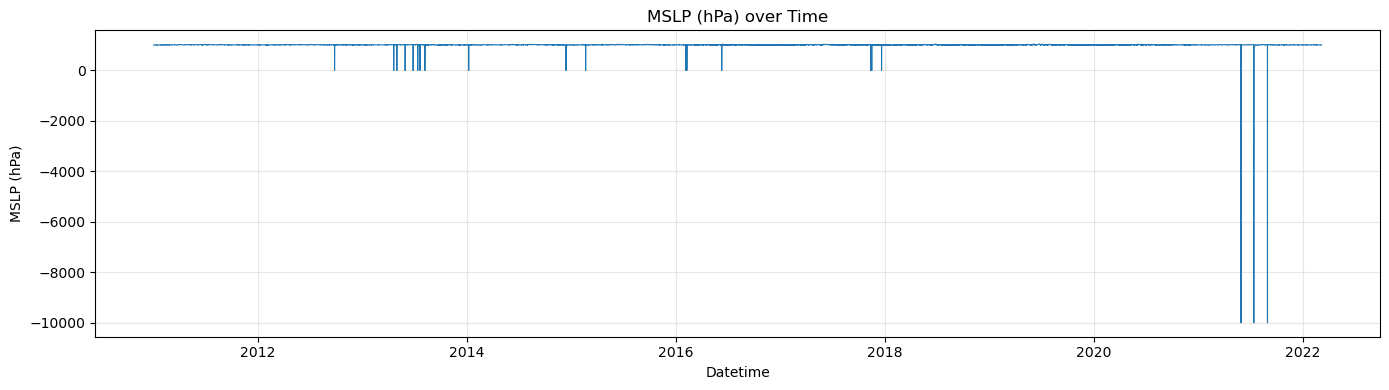

In [9]:
# Plotting MSLP (hPa) over time before cleaning

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['MSLP (hPa)'], linewidth=0.8)
plt.title('MSLP (hPa) over Time')
plt.xlabel('Datetime')
plt.ylabel('MSLP (hPa)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

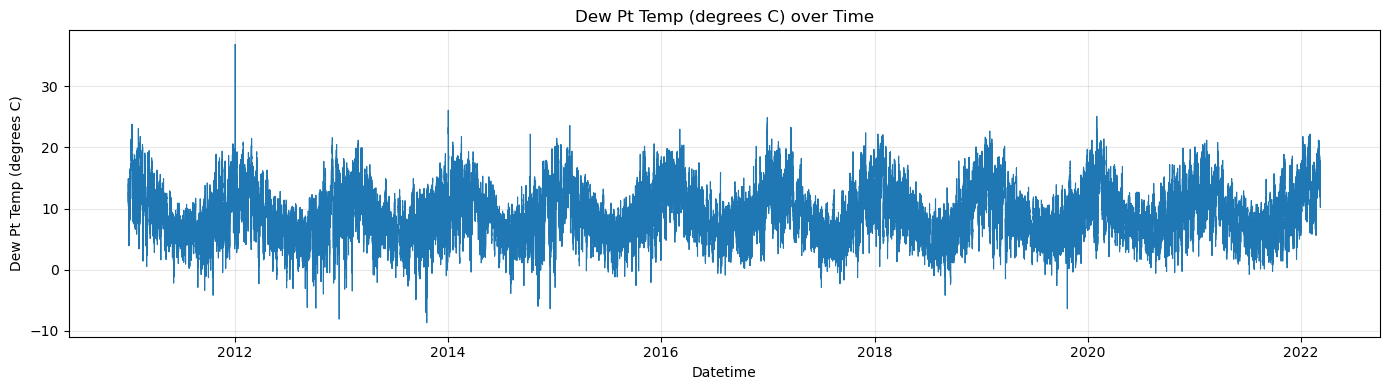

In [10]:
# Plotting Dew Pt Temp (degrees C) over time before cleaning

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Dew Pt Temp (degrees C)'], linewidth=0.8)
plt.title('Dew Pt Temp (degrees C) over Time')
plt.xlabel('Datetime')
plt.ylabel('Dew Pt Temp (degrees C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

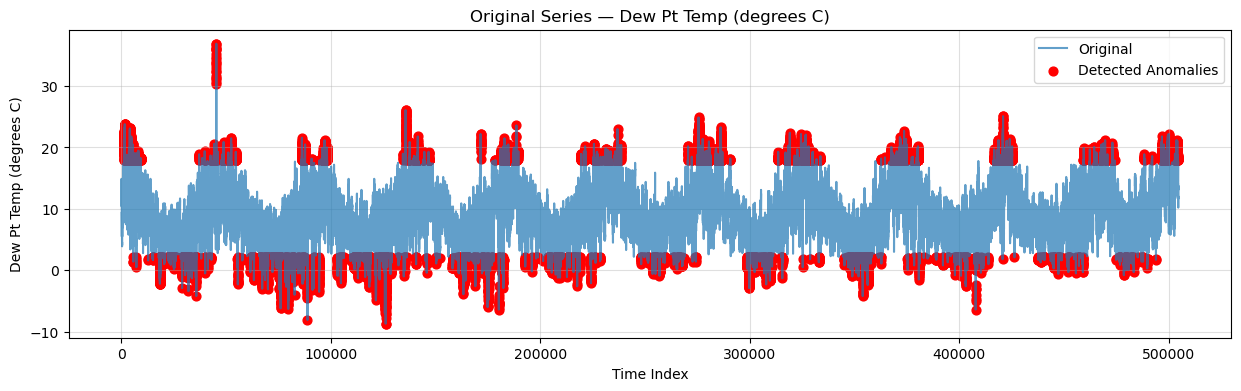

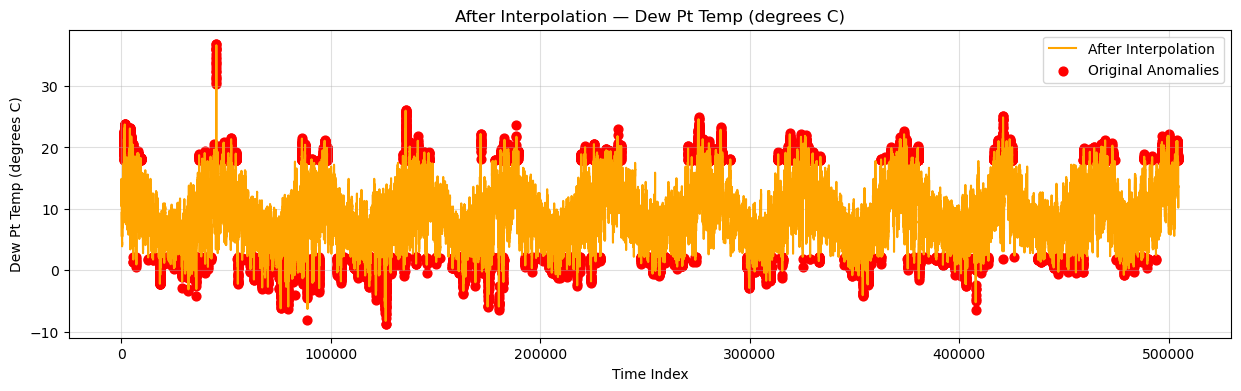

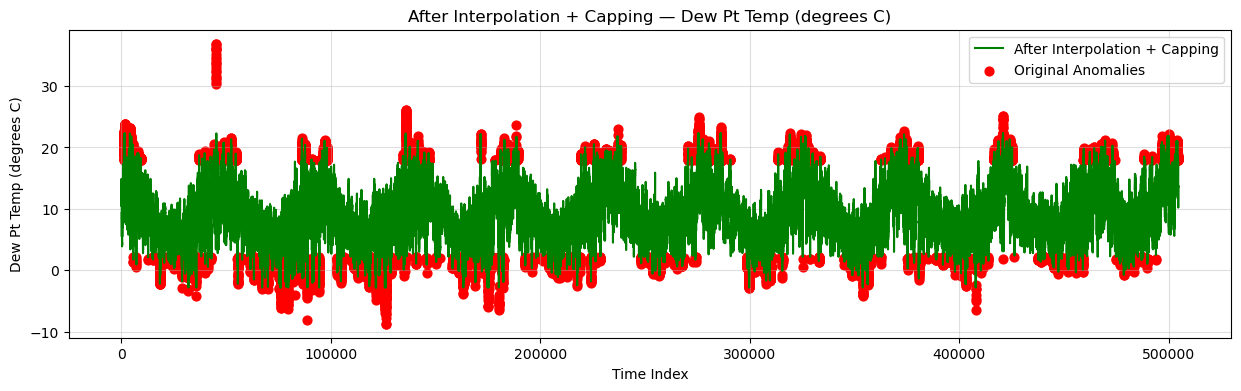

In [11]:
# choose any continuous feature as an example for anomaly detection and cleaning

col = 'Dew Pt Temp (degrees C)'

original = mel_data[col].copy()

lower = original.quantile(0.025)
upper = original.quantile(0.975)

outlier_mask = (original < lower) | (original > upper)

interpolated = original.copy()
interpolated[outlier_mask] = (original.shift(1) + original.shift(-1)) / 2

capped = interpolated.clip(original.quantile(0.0005), original.quantile(0.9995))

# -----------------------------
# Plot 1 — Original
# -----------------------------
plt.figure(figsize=(15, 4))
plt.plot(original.values, label="Original", alpha=0.7)
plt.scatter(
    np.where(outlier_mask)[0],
    original[outlier_mask],
    color="red",
    s=40,
    label="Detected Anomalies"
)
plt.title(f"Original Series — {col}")
plt.xlabel("Time Index")
plt.ylabel(col)
plt.grid(alpha=0.4)
plt.legend()
plt.show()

# -----------------------------
# Plot 2 — After Interpolation Only
# -----------------------------
plt.figure(figsize=(15, 4))
plt.plot(interpolated.values, label="After Interpolation", color="orange")
plt.scatter(
    np.where(outlier_mask)[0],
    original[outlier_mask],
    color="red",
    s=40,
    label="Original Anomalies"
)
plt.title(f"After Interpolation — {col}")
plt.xlabel("Time Index")
plt.ylabel(col)
plt.grid(alpha=0.4)
plt.legend()
plt.show()

# -----------------------------
# Plot 3 — After Interpolation + Capping
# -----------------------------
plt.figure(figsize=(15, 4))
plt.plot(capped.values, label="After Interpolation + Capping", color="green")
plt.scatter(
    np.where(outlier_mask)[0],
    original[outlier_mask],
    color="red",
    s=40,
    label="Original Anomalies"
)
plt.title(f"After Interpolation + Capping — {col}")
plt.xlabel("Time Index")
plt.ylabel(col)
plt.grid(alpha=0.4)
plt.legend()
plt.show()


In [12]:
# For continuous columns, identify outliers using the 2.5th and 97.5th percentiles (fixed quantile trimming).
# Interpolate with the average of their immediate neighbors (interpolation).

continuous_cols = [
    'Air Temp (degrees C)',
    'Apparent Temp (degrees C)',
    'Dew Pt Temp (degrees C)',
    'Humidity (%)',
    'Wind Speed (km/h)',
    'MSLP (hPa)',
    'E (hPa)',
    'gamma',
    'Calculated Dew Pt Temp (degrees C)',
    'Calculated Apparent Temp (degrees C)'
]

for col in continuous_cols:
    lower = mel_data[col].quantile(0.025)
    upper = mel_data[col].quantile(0.975)

    outlier = (mel_data[col] < lower) | (mel_data[col] > upper)

    interpolated = (mel_data[col].shift(1) + mel_data[col].shift(-1)) / 2

    interpolated = interpolated.clip(mel_data[col].quantile(0.0005), mel_data[col].quantile(0.9995))

    mel_data.loc[outlier, col] = interpolated[outlier]

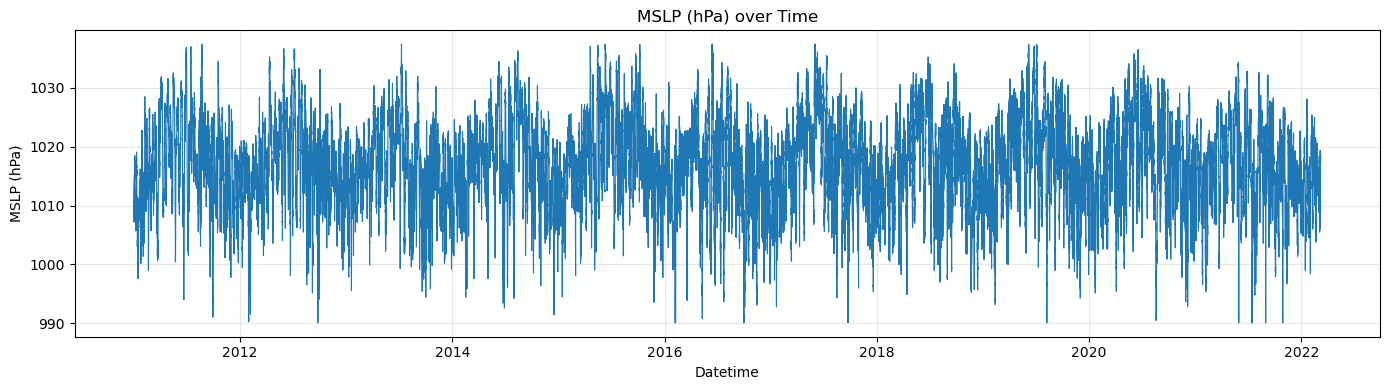

In [13]:
# Plotting MSLP (hPa) over time after cleaning

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['MSLP (hPa)'], linewidth=0.8)
plt.title('MSLP (hPa) over Time')
plt.xlabel('Datetime')
plt.ylabel('MSLP (hPa)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

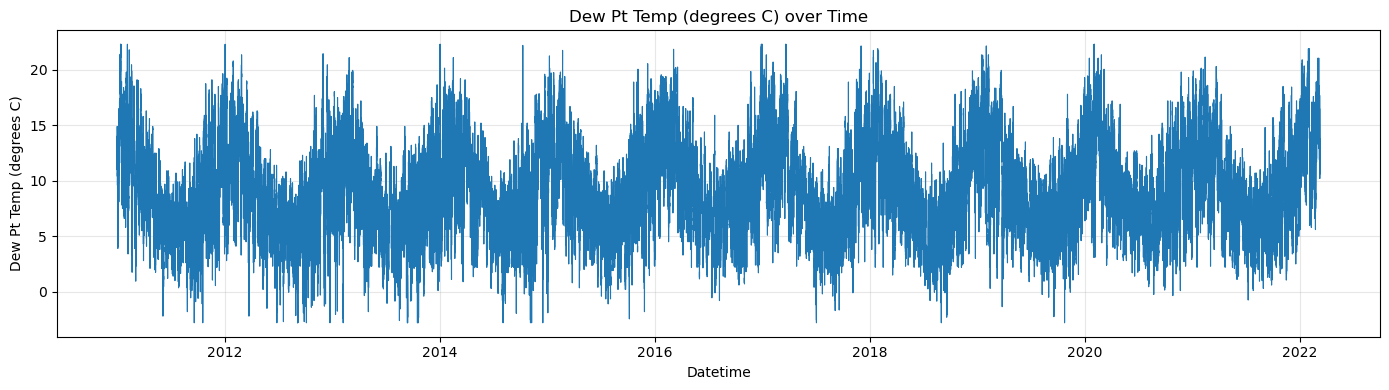

In [14]:
# Plotting Dew Pt Temp (degrees C) over time after cleaning

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Dew Pt Temp (degrees C)'], linewidth=0.8)
plt.title('Dew Pt Temp (degrees C) over Time')
plt.xlabel('Datetime')
plt.ylabel('Dew Pt Temp (degrees C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Visually check discontinuous columns

discontinuous_cols = mel_data.columns.difference(continuous_cols)
discontinuous_cols

Index(['Datetime', 'Rainfall since 9 am (mm)', 'Wind Direction',
       'Wind Gust  (km/h)'],
      dtype='object')

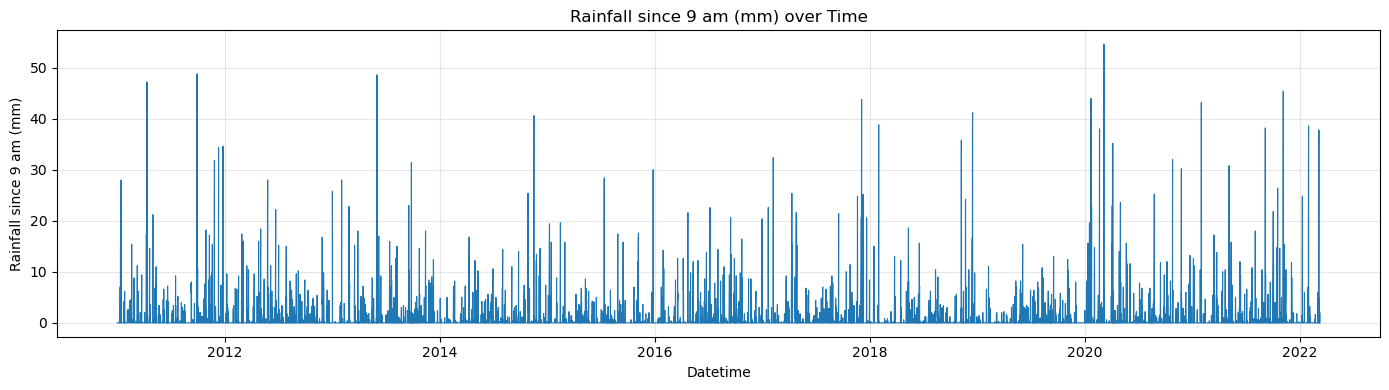

In [16]:
# Valid rainfall data should be non-negative. Check for negative values in the "Rainfall since 9 am (mm)" column and handle them if necessary.

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Rainfall since 9 am (mm)'], linewidth=0.8)
plt.title('Rainfall since 9 am (mm) over Time')
plt.xlabel('Datetime')
plt.ylabel('Rainfall since 9 am (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

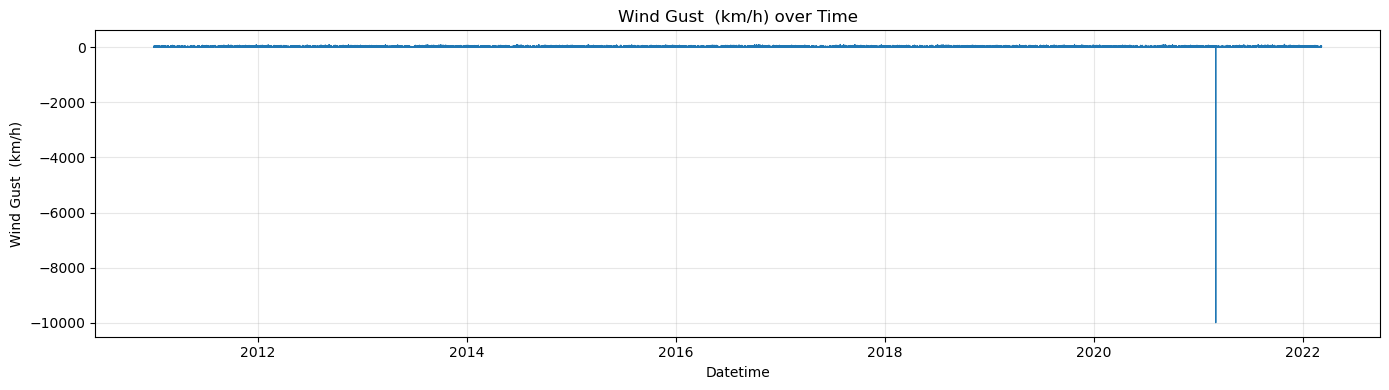

In [17]:
# Valid wind gust data should be non-negative. Check for negative values in the "Wind Gust  (km/h)" column and handle them if necessary.

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Wind Gust  (km/h)'], linewidth=0.8)
plt.title('Wind Gust  (km/h) over Time')
plt.xlabel('Datetime')
plt.ylabel('Wind Gust  (km/h)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
len([mel_data['Wind Gust  (km/h)'] < 0])

1

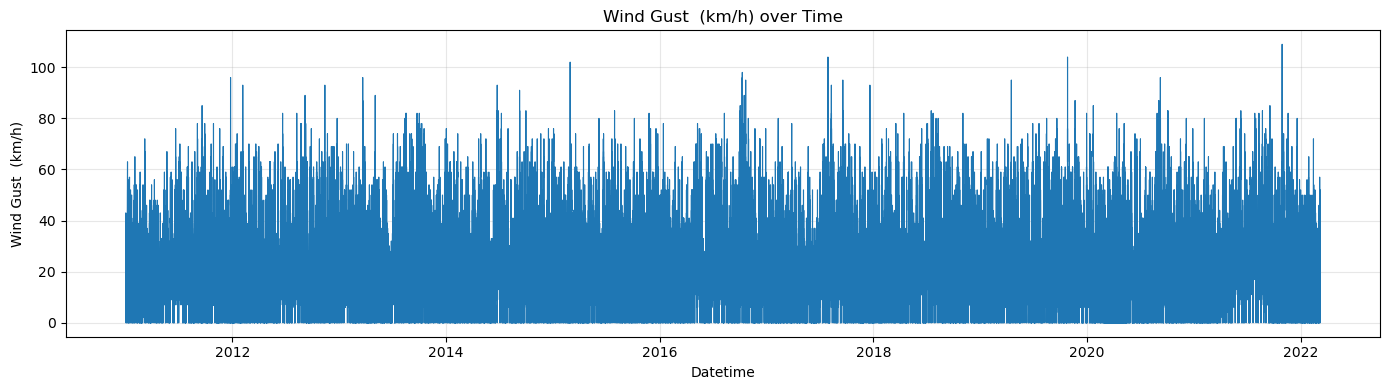

In [19]:
mel_data = mel_data[mel_data['Wind Gust  (km/h)'] >= 0]

plt.figure(figsize=(14, 4))
plt.plot(mel_data['Datetime'], mel_data['Wind Gust  (km/h)'], linewidth=0.8)
plt.title('Wind Gust  (km/h) over Time')
plt.xlabel('Datetime')
plt.ylabel('Wind Gust  (km/h)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Valid wind direction data should not be numeric values. Check for unique values in the "Wind Direction" column to identify any invalid entries.

mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', 1016.6, 1016.9, 1017,
       1017.4, 1026, 1026.1, 1025.3, 1024.2, 1029.6, 1003.3, 1008.2, 1019,
       1015.5, 1014.2, 1015.9, 1016.2, 1016.1, 1014.1, 1014, 1013.6,
       1012.7, 1013.1, 1014.4, 1014.6, 1015.6, 1015.8, 1016.7, 1017.2,
       1016, 1017.8, 1019.5, 1019.8, 1019.9, 1020.4, 1021, 1021.2, 1021.7,
       1021.9, 1022.3, 1022.7, 1004.5, 1022, 1010.3, 1012, 1010.8],
      dtype=object)

In [21]:
valid_dr = ['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW', 'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM']
len(mel_data[~mel_data['Wind Direction'].isin(valid_dr)])

56

In [22]:
mel_data = mel_data[mel_data['Wind Direction'].isin(valid_dr)]
mel_data['Wind Direction'].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM'], dtype=object)

In [23]:
# One-hot encode the "Wind Direction" column and drop the original column.
# Even though circular encoding using sine and cosine can capture geometric relationships, 
# one-hot encoding is more interpretable for tree-based models and can still capture the necessary information without introducing complexity.

dummies=pd.get_dummies(mel_data['Wind Direction'], prefix='WindDir')
mel_data_oh = mel_data.join(dummies).drop(columns=['Wind Direction'])

mel_data_oh

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,24.8,0.0,14.0,51.0,11.0,13.0,1007.4,0.0,0.969609,14.1,...,False,False,False,True,False,False,False,False,False,False
1,24.8,0.0,13.3,48.0,11.0,11.0,1007.5,0.0,0.908985,13.2,...,False,False,False,True,False,False,False,False,False,False
2,24.9,0.0,13.3,48.0,11.0,13.0,1007.5,0.0,0.915025,13.2,...,False,False,False,True,False,False,False,False,False,False
3,24.7,0.0,13.4,49.0,11.0,11.0,1007.4,0.0,0.923560,13.4,...,False,False,False,True,False,False,False,False,False,False
4,24.1,0.0,13.3,51.0,9.0,9.0,1007.3,0.0,0.927209,13.4,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505350,18.6,16.0,13.2,71.0,39.0,46.0,1018.0,0.0,0.917431,13.3,...,False,False,False,False,False,True,False,False,False,False
505351,18.7,18.5,13.6,72.0,35.0,46.0,1017.9,0.0,0.937732,13.6,...,False,False,False,False,False,True,False,False,False,False
505352,18.9,17.6,13.7,72.0,35.0,41.0,1017.8,0.0,0.950348,13.8,...,False,False,False,False,False,True,False,False,False,False
505353,19.2,18.3,13.8,71.0,32.0,35.0,1017.8,0.0,0.955250,13.9,...,False,False,True,False,False,False,False,False,False,False


In [24]:
# Daily Aggregation

wind_cols = [c for c in mel_data_oh.columns if c.startswith('WindDir_')]

daily_data = mel_data_oh.resample('D', on='Datetime').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': ['mean', 'max', 'min'],
    'Humidity (%)': ['mean', 'max', 'min'],
    'MSLP (hPa)': ['mean', 'max', 'min'],
    'Wind Speed (km/h)': ['mean', 'max', 'min'],
    'Wind Gust  (km/h)': ['max', 'min'],
    'E (hPa)': ['mean', 'max', 'min'],
    'Dew Pt Temp (degrees C)': ['mean', 'max', 'min'],
    'Apparent Temp (degrees C)': ['mean', 'max', 'min'],
    'Rainfall since 9 am (mm)': 'last'
})

daily_data['RainTomorrow'] = (daily_data['Rainfall since 9 am (mm)'].shift(-1) > 0)

daily_data

WindDir_CALM WindDir_E WindDir_ENE WindDir_ESE WindDir_N  \
                   mean      mean        mean        mean      mean   
Datetime                                                              
2011-01-01         0.00     0.000    0.038760    0.015504  0.007752   
2011-01-02         0.00     0.000    0.000000    0.000000  0.000000   
2011-01-03         0.00     0.000    0.000000    0.007692  0.000000   
2011-01-04         0.00     0.000    0.000000    0.000000  0.000000   
2011-01-05         0.00     0.000    0.000000    0.000000  0.000000   
...                 ...       ...         ...         ...       ...   
2022-03-04         0.12     0.032    0.016000    0.016000  0.272000   
2022-03-05         0.00     0.000    0.015038    0.000000  0.007519   
2022-03-06         0.00     0.000    0.000000    0.000000  0.007692   
2022-03-07         0.00     0.000    0.000000    0.000000  0.016807   
2022-03-08         0.00     0.000    0.000000    0.000000  0.000000   

           WindDir_NE WindDir_NNE WindDir_NNW WindDir_NW WindDir_S  ...  \
                 mean        mean        mean       mean      mean  ...   
Datetime                                                            ...   
2011-01-01   0.015504    0.007752    0.000000   0.023256  0.418605  ...   
2011-01-02   0.000000    0.000000    0.000000   0.000000  0.632653  ...   
2011-01-03   0.000000    0.000000    0.000000   0.000000  0.446154  ...   
2011-01-04   0.000000    0.000000    0.007752   0.000000  0.255814  ...   
2011-01-05   0.000000    0.000000    0.000000   0.007752  0.418605  ...   
...               ...         ...         ...        ...       ...  ...   
2022-03-04   0.024000    0.048000    0.064000   0.072000  0.056000  ...   
2022-03-05   0.022556    0.000000    0.000000   0.007519  0.195489  ...   
2022-03-06   0.000000    0.000000    0.000000   0.000000  0.000000  ...   
2022-03-07   0.000000    0.000000    0.000000   0.016807  0.084034  ...   
2022-03-08   0.000000    0.000000    0.000000   0.000000  0.494382  ...   

              E (hPa)            Dew Pt Temp (degrees C)               \
                  max        min                    mean    max   min   
Datetime                                                                
2011-01-01  16.879444  11.846629               12.004651  14.90   9.6   
2011-01-02  13.447486   8.833384                8.087755  11.40   5.2   
2011-01-03  10.048411   8.068491                5.462308   7.10   3.9   
2011-01-04  14.287514   9.351915                8.866667  12.40   6.2   
2011-01-05  15.055950  11.836166               11.719380  13.20   9.7   
...               ...        ...                     ...    ...   ...   
2022-03-04  24.834724  14.822663               16.654400  21.05  12.9   
2022-03-05  24.251059  17.646472               17.528947  20.65  15.6   
2022-03-06  20.916013  14.007865               14.631538  18.25  12.0   
2022-03-07  19.847726  13.935241               14.105882  17.40  11.9   
2022-03-08  20.205844  12.416417               13.046067  17.70  10.2   

           Apparent Temp (degrees C)             Rainfall since 9 am (mm)  \
                                mean   max   min                     last   
Datetime                                                                    
2011-01-01                  0.000000   0.0   0.0                      0.0   
2011-01-02                  0.000000   0.0   0.0                      0.0   
2011-01-03                  0.000000   0.0   0.0                      0.0   
2011-01-04                  0.000000   0.0   0.0                      0.0   
2011-01-05                  0.000000   0.0   0.0                      0.0   
...                              ...   ...   ...                      ...   
2022-03-04                 25.409200  32.2  18.7                      3.8   
2022-03-05                 20.012030  24.5  17.5                      1.2   
2022-03-06                 17.083077  21.6  13.7                      0.0   
2022-03-07        

In [25]:
daily_data['RainTomorrow'].unique()

array([False,  True])

In [26]:
daily_data['Rainfall since 9 am (mm)']

,last
Datetime,
2011-01-01,0.0
2011-01-02,0.0
2011-01-03,0.0
2011-01-04,0.0
2011-01-05,0.0
...,...
2022-03-04,3.8
2022-03-05,1.2
2022-03-06,0.0


In [27]:
# Lag Feature Creation for 3 days

continuous_cols = daily_data.columns.tolist()[17:-2]

max_lag = 3
lag_features = []

for col in continuous_cols:
    for lag in range(1, max_lag + 1):
        lag_features.append(
            daily_data[col].shift(lag).rename(f"{col}_lag{lag}")
        )

lag_block = pd.concat(lag_features, axis=1)

lag_daily = pd.concat([daily_data, lag_block], axis=1)

lag_daily = lag_daily.dropna().copy()

lag_daily

,"(WindDir_CALM, mean)","(WindDir_E, mean)","(WindDir_ENE, mean)","(WindDir_ESE, mean)","(WindDir_N, mean)","(WindDir_NE, mean)","(WindDir_NNE, mean)","(WindDir_NNW, mean)","(WindDir_NW, mean)","(WindDir_S, mean)",...,"('Dew Pt Temp (degrees C)', 'min')_lag3","('Apparent Temp (degrees C)', 'mean')_lag1","('Apparent Temp (degrees C)', 'mean')_lag2","('Apparent Temp (degrees C)', 'mean')_lag3","('Apparent Temp (degrees C)', 'max')_lag1","('Apparent Temp (degrees C)', 'max')_lag2","('Apparent Temp (degrees C)', 'max')_lag3","('Apparent Temp (degrees C)', 'min')_lag1","('Apparent Temp (degrees C)', 'min')_lag2","('Apparent Temp (degrees C)', 'min')_lag3"
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-04,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.007752,0.000000,0.255814,...,9.6,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0
2011-01-05,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,5.2,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0
2011-01-06,0.00,0.008,0.016000,0.016,0.136000,0.008000,0.032000,0.056000,0.088000,0.152000,...,3.9,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0
2011-01-07,0.00,0.000,0.000000,0.000,0.821705,0.000000,0.178295,0.000000,0.000000,0.000000,...,6.2,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0
2011-01-08,0.00,0.000,0.000000,0.000,0.567568,0.000000,0.081081,0.054054,0.040541,0.094595,...,9.7,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,16.8,24.725984,25.291860,24.676718,30.75,29.70,27.45,19.8,0.0,22.1
2022-03-05,0.00,0.000,0.015038,0.000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,13.3,25.409200,24.725984,25.291860,32.20,30.75,29.70,18.7,19.8,0.0
2022-03-06,0.00,0.000,0.000000,0.000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.6,20.012030,25.409200,24.725984,24.50,32.20,30.75,17.5,18.7,19.8


# Modelling

In [28]:
from sklearn.model_selection import TimeSeriesSplit, train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel

## Baseline
Baseline accuracy is the proportion of days with no rain;
Any real model must have accuracy greater than or equal to the baseline accuracy.

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_df = daily_data.copy()
X = baseline_df.drop(columns=['RainTomorrow'])
y = baseline_df['RainTomorrow'].astype(int)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)

y_pred = dummy.predict(X)
baseline_accuracy = accuracy_score(y, y_pred)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.6886168910648715


## Normal Random Forest
Randomly mixing dates causes data leakage.

In [30]:
model_df_RF = daily_data.copy()

X_RF = model_df_RF.drop(columns=['RainTomorrow'])
y_RF = model_df_RF['RainTomorrow'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_RF, y_RF, test_size=0.2, shuffle=True, random_state=42
)

rf_RF = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_RF.fit(X_train, y_train)
y_pred = rf_RF.predict(X_test)
y_prob = rf_RF.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7282741738066095
Precision: 0.6344827586206897
Recall: 0.3524904214559387
F1: 0.45320197044334976
ROC-AUC: 0.751912263292814


## Random Forest with Stratified K-Fold Cross Validation
Each fold contains random mixture of years, which causes data leakage.

In [31]:
model_df_ncv = daily_data.copy()

X_ncv = model_df_ncv.drop(columns=['RainTomorrow'])
y_ncv = model_df_ncv['RainTomorrow'].astype(int)

rf_NCV = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(rf_NCV, X_ncv, y_ncv, cv=skf, scoring='f1')
auc_scores = cross_val_score(rf_NCV, X_ncv, y_ncv, cv=skf, scoring='roc_auc')

print("Mean F1 (random CV):", f1_scores.mean())
print("Mean AUC (random CV):", auc_scores.mean())

Mean F1 (random CV): 0.40584323749173856
Mean AUC (random CV): 0.7464896614329267


## Random Forest with Time Series Cross Validation

### Daily Dataset

In [32]:
model_df_TSCV = daily_data.copy()

X_TSCV = model_df_TSCV.drop(columns=['RainTomorrow'])
y_TSCV = model_df_TSCV['RainTomorrow'].astype(int)

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV, y_TSCV)

best_rf_TSCV_Ori = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}


In [33]:
train_idx, test_idx = list(tscv.split(X_TSCV))[-1]

X_train, X_test = X_TSCV.iloc[train_idx], X_TSCV.iloc[test_idx]
y_train, y_test_ori = y_TSCV.iloc[train_idx], y_TSCV.iloc[test_idx]

best_rf_TSCV_Ori.fit(X_train, y_train)

y_pred_ori = best_rf_TSCV_Ori.predict(X_test)
y_prob_ori = best_rf_TSCV_Ori.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_ori, y_pred_ori))
print("Precision:", precision_score(y_test_ori, y_pred_ori))
print("Recall:", recall_score(y_test_ori, y_pred_ori))
print("F1:", f1_score(y_test_ori, y_pred_ori))
print("ROC-AUC:", roc_auc_score(y_test_ori, y_prob_ori))

Accuracy: 0.6926470588235294
Precision: 0.4936708860759494
Recall: 0.7609756097560976
F1: 0.5988483685220729
ROC-AUC: 0.7525956354300385


In [34]:
importances = pd.Series(best_rf_TSCV_Ori.feature_importances_, index=X_TSCV.columns)
importances.sort_values(ascending=False).head(10)

MSLP (hPa)                min     0.110490
                          mean    0.099726
WindDir_SSE               mean    0.094090
MSLP (hPa)                max     0.088323
WindDir_S                 mean    0.080267
Rainfall since 9 am (mm)  last    0.069569
WindDir_SSW               mean    0.035157
Wind Speed (km/h)         mean    0.027119
WindDir_N                 mean    0.026435
Wind Gust  (km/h)         max     0.024867
dtype: float64

## Feature Selection

In [35]:
train_idx, test_idx = list(tscv.split(X_TSCV))[-1]

X_train_raw = X_TSCV.iloc[train_idx].copy()
X_test_raw  = X_TSCV.iloc[test_idx].copy()

y_train = y_TSCV.iloc[train_idx].copy()
y_test  = y_TSCV.iloc[test_idx].copy()

In [36]:
X_train = X_train_raw.dropna()
X_test  = X_test_raw.dropna()

y_train = y_train.loc[X_train.index]
y_test  = y_test.loc[X_test.index]

In [37]:
selector = SelectFromModel(best_rf_TSCV_Ori, threshold="median")
selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)

print("Original features:", X_train.shape[1])
print("Selected features:", X_train_sel.shape[1])

Original features: 41
Selected features: 21


In [38]:
rf_selected = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    **grid.best_params_
)

rf_selected.fit(X_train_sel, y_train)

y_pred_sel = rf_selected.predict(X_test_sel)
y_prob_sel = rf_selected.predict_proba(X_test_sel)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_sel))
print("Precision:", precision_score(y_test, y_pred_sel))
print("Recall:", recall_score(y_test, y_pred_sel))
print("F1:", f1_score(y_test, y_pred_sel))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_sel))

Accuracy: 0.678939617083947
Precision: 0.48
Recall: 0.7609756097560976
F1: 0.5886792452830188
ROC-AUC: 0.7533497993207781


### Lagged Daily Dataset

In [48]:
model_df_TSCV_Lag = lag_daily.copy()

y_TSCV_Lag = model_df_TSCV_Lag[('RainTomorrow', '')].astype(int)
X_TSCV_Lag = model_df_TSCV_Lag.drop(columns=[('RainTomorrow', '')])
X_TSCV_Lag.columns = X_TSCV_Lag.columns.astype(str)

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV_Lag = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV_Lag,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV_Lag, y_TSCV_Lag)

best_rf_TSCV_Lag = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}


In [49]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag))[-1]

X_train, X_test = X_TSCV_Lag.iloc[train_idx], X_TSCV_Lag.iloc[test_idx]
y_train, y_test_lag3 = y_TSCV_Lag.iloc[train_idx], y_TSCV_Lag.iloc[test_idx]

best_rf_TSCV_Lag.fit(X_train, y_train)

y_pred_lag3 = best_rf_TSCV_Lag.predict(X_test)
y_prob_lag3 = best_rf_TSCV_Lag.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag3, y_pred_lag3))
print("Precision:", precision_score(y_test_lag3, y_pred_lag3))
print("Recall:", recall_score(y_test_lag3, y_pred_lag3))
print("F1:", f1_score(y_test_lag3, y_pred_lag3))
print("ROC-AUC:", roc_auc_score(y_test_lag3, y_prob_lag3))

Accuracy: 0.689807976366322
Precision: 0.49328859060402686
Recall: 0.7135922330097088
F1: 0.5833333333333334
ROC-AUC: 0.7518706326139384


<Figure size 800x1500 with 0 Axes>

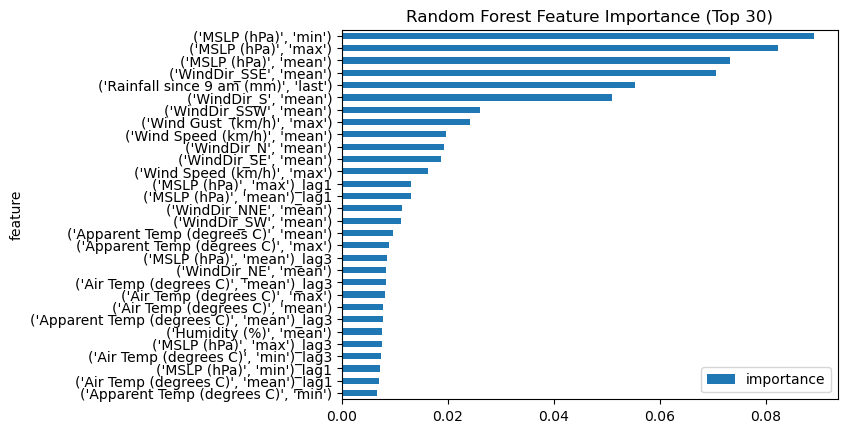

In [50]:
importance = pd.DataFrame({
    "feature": X_TSCV_Lag.columns,
    "importance": best_rf_TSCV_Lag.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 15))
importance.head(30).plot(kind='barh', x='feature', y='importance')
plt.title("Random Forest Feature Importance (Top 30)")
plt.gca().invert_yaxis()
plt.show()

### Lag Adjustment (Lag Window = lag1)

In [51]:
lag_daily_one = daily_data.copy()

for col in continuous_cols:
    for lag in range(1, 2):
        lag_daily_one[f"{col}_lag{lag}"] = lag_daily_one[col].shift(lag)

lag_daily_one = lag_daily_one.dropna()
lag_daily_one

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,"('Wind Gust (km/h)', 'min')_lag1","('E (hPa)', 'mean')_lag1","('E (hPa)', 'max')_lag1","('E (hPa)', 'min')_lag1","('Dew Pt Temp (degrees C)', 'mean')_lag1","('Dew Pt Temp (degrees C)', 'max')_lag1","('Dew Pt Temp (degrees C)', 'min')_lag1","('Apparent Temp (degrees C)', 'mean')_lag1","('Apparent Temp (degrees C)', 'max')_lag1","('Apparent Temp (degrees C)', 'min')_lag1"
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.632653,...,0.0,13.980619,16.879444,11.846629,12.004651,14.90,9.6,0.000000,0.00,0.0
2011-01-03,0.00,0.000,0.000000,0.007692,0.000000,0.000000,0.000,0.000000,0.000000,0.446154,...,13.0,10.760363,13.447486,8.833384,8.087755,11.40,5.2,0.000000,0.00,0.0
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.007752,0.000000,0.255814,...,17.0,8.949827,10.048411,8.068491,5.462308,7.10,3.9,0.000000,0.00,0.0
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.007752,0.418605,...,0.0,11.376651,14.287514,9.351915,8.866667,12.40,6.2,0.000000,0.00,0.0
2011-01-06,0.00,0.008,0.016000,0.016000,0.136000,0.008000,0.032,0.056000,0.088000,0.152000,...,0.0,13.699222,15.055950,11.836166,11.719380,13.20,9.7,0.000000,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048,0.064000,0.072000,0.056000,...,0.0,18.410571,20.751503,15.486953,16.237008,18.10,13.6,24.725984,30.75,19.8
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000,0.000000,0.007519,0.195489,...,0.0,18.998923,24.834724,14.822663,16.654400,21.05,12.9,25.409200,32.20,18.7


In [53]:
model_df_TSCV_Lag_One = lag_daily_one.copy()

y_TSCV_Lag_One = model_df_TSCV_Lag_One[('RainTomorrow', '')].astype(int)
X_TSCV_Lag_One = model_df_TSCV_Lag_One.drop(columns=[('RainTomorrow', '')])

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV_Lag_One = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV_Lag_One,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV_Lag_One, y_TSCV_Lag_One)

best_rf_TSCV_Lag_One = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}


In [54]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag_One))[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test_lag1 = y.iloc[train_idx], y.iloc[test_idx]

best_rf_TSCV_Lag_One.fit(X_train, y_train)

y_pred_lag1 = best_rf_TSCV_Lag_One.predict(X_test)
y_prob_lag1 = best_rf_TSCV_Lag_One.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag1, y_pred_lag1))
print("Precision:", precision_score(y_test_lag1, y_pred_lag1))
print("Recall:", recall_score(y_test_lag1, y_pred_lag1))
print("F1:", f1_score(y_test_lag1, y_pred_lag1))
print("ROC-AUC:", roc_auc_score(y_test_lag1, y_prob_lag1))

Accuracy: 0.6828908554572272
Precision: 0.48417721518987344
Recall: 0.7463414634146341
F1: 0.5873320537428023
ROC-AUC: 0.74854844531532


### Lag Adjustment (Lag Window = lag1 or lag2 or lag3 among top 30 feature importance)

In [55]:
Lag_importance = pd.DataFrame(importance.head(30))
lag1_cols = [col for col in Lag_importance['feature'] if col.endswith(("lag1", "lag2", "lag3"))]
Lag_importance['feature']
lag1_cols

["('MSLP (hPa)', 'max')_lag1",
 "('MSLP (hPa)', 'mean')_lag1",
 "('MSLP (hPa)', 'mean')_lag3",
 "('Air Temp (degrees C)', 'mean')_lag3",
 "('Apparent Temp (degrees C)', 'mean')_lag3",
 "('MSLP (hPa)', 'max')_lag3",
 "('Air Temp (degrees C)', 'min')_lag3",
 "('MSLP (hPa)', 'min')_lag1",
 "('Air Temp (degrees C)', 'mean')_lag1"]

In [56]:
lag_daily_one_partial = daily_data.copy()

for col in continuous_cols:
    if f"{col}_lag1" in lag1_cols:
        lag_daily_one_partial[f"{col}_lag1"] = lag_daily_one_partial[col].shift(1)
    if f"{col}_lag2" in lag1_cols:
        lag_daily_one_partial[f"{col}_lag2"] = lag_daily_one_partial[col].shift(2)
    if f"{col}_lag3" in lag1_cols:
        lag_daily_one_partial[f"{col}_lag3"] = lag_daily_one_partial[col].shift(3)

lag_daily_one_partial = lag_daily_one_partial.dropna()
lag_daily_one_partial

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,RainTomorrow,"('Air Temp (degrees C)', 'mean')_lag1","('Air Temp (degrees C)', 'mean')_lag3","('Air Temp (degrees C)', 'min')_lag3","('MSLP (hPa)', 'mean')_lag1","('MSLP (hPa)', 'mean')_lag3","('MSLP (hPa)', 'max')_lag1","('MSLP (hPa)', 'max')_lag3","('MSLP (hPa)', 'min')_lag1","('Apparent Temp (degrees C)', 'mean')_lag3"
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-04,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.007752,0.000000,0.255814,...,False,16.583846,19.651938,16.8,1016.946154,1011.784496,1018.5,1015.2,1015.6,0.000000
2011-01-05,0.00,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,False,16.780620,18.169388,15.3,1012.396899,1016.310204,1016.3,1017.6,1009.7,0.000000
2011-01-06,0.00,0.008,0.016000,0.016,0.136000,0.008000,0.032000,0.056000,0.088000,0.152000,...,False,18.110853,16.583846,14.1,1010.086047,1016.946154,1012.4,1018.5,1008.2,0.000000
2011-01-07,0.00,0.000,0.000000,0.000,0.821705,0.000000,0.178295,0.000000,0.000000,0.000000,...,True,22.252000,16.780620,12.9,1008.888000,1012.396899,1012.5,1016.3,1005.7,0.000000
2011-01-08,0.00,0.000,0.000000,0.000,0.567568,0.000000,0.081081,0.054054,0.040541,0.094595,...,True,27.413566,18.110853,14.6,1007.706202,1010.086047,1009.4,1012.4,1006.4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,True,23.502756,22.188550,19.9,1012.637008,1010.818321,1014.6,1012.7,1011.0,24.676718
2022-03-05,0.00,0.000,0.015038,0.000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,False,24.474000,23.833333,19.8,1009.955200,1011.687597,1013.0,1013.3,1006.9,25.291860


In [58]:
model_df_TSCV_Lag_One_Partial = lag_daily_one_partial.copy()

y_TSCV_Lag_One_Partial = model_df_TSCV_Lag_One_Partial[('RainTomorrow', '')].astype(int)
X_TSCV_Lag_One_Partial = model_df_TSCV_Lag_One_Partial.drop(columns=[('RainTomorrow', '')])

tscv = TimeSeriesSplit(n_splits=5)

rf_TSCV_Lag_One_Partial = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_TSCV_Lag_One_Partial,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_TSCV_Lag_One_Partial, y_TSCV_Lag_One_Partial)

best_rf_TSCV_Lag_One_Partial = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 400}


In [59]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag_One_Partial))[-1]

X_train, X_test = X_TSCV_Lag_One_Partial.iloc[train_idx], X_TSCV_Lag_One_Partial.iloc[test_idx]
y_train, y_test_lag1_partial = y_TSCV_Lag_One_Partial.iloc[train_idx], y_TSCV_Lag_One_Partial.iloc[test_idx]

best_rf_TSCV_Lag_One_Partial.fit(X_train, y_train)

y_pred_lag1_partial = best_rf_TSCV_Lag_One_Partial.predict(X_test)
y_prob_lag1_partial = best_rf_TSCV_Lag_One_Partial.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag1_partial, y_pred_lag1_partial))
print("Precision:", precision_score(y_test_lag1_partial, y_pred_lag1_partial))
print("Recall:", recall_score(y_test_lag1_partial, y_pred_lag1_partial))
print("F1:", f1_score(y_test_lag1_partial, y_pred_lag1_partial))
print("ROC-AUC:", roc_auc_score(y_test_lag1_partial, y_prob_lag1_partial))

Accuracy: 0.691285081240768
Precision: 0.4935483870967742
Recall: 0.7463414634146341
F1: 0.5941747572815534
ROC-AUC: 0.7555704836709384


### Feature Selection for Lagged Daily Dataset

In [60]:
train_idx, test_idx = list(tscv.split(X_TSCV_Lag))[-1]

X_train_raw_lag = X_TSCV_Lag.iloc[train_idx].copy()
X_test_raw_lag  = X_TSCV_Lag.iloc[test_idx].copy()

y_train_lag = y_TSCV_Lag.iloc[train_idx].copy()
y_test_lag  = y_TSCV_Lag.iloc[test_idx].copy()

X_train_lag = X_train_raw_lag.dropna()
X_test_lag  = X_test_raw_lag.dropna()

y_train_lag = y_train_lag.loc[X_train_lag.index]
y_test_lag  = y_test_lag.loc[X_test_lag.index]

selector_lag = SelectFromModel(best_rf_TSCV_Lag, threshold="median")
selector_lag.fit(X_train_lag, y_train_lag)

X_train_sel_lag = selector_lag.transform(X_train_lag)
X_test_sel_lag  = selector_lag.transform(X_test_lag)

print("Original features:", X_train_lag.shape[1])
print("Selected features:", X_train_sel_lag.shape[1])

Original features: 110
Selected features: 55


In [61]:
lag_best_params = {k: best_rf_TSCV_Lag.get_params()[k]
                   for k in ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features']}

rf_selected_lag = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    **lag_best_params
)

rf_selected_lag.fit(X_train_sel_lag, y_train_lag)

y_pred_sel_lag = rf_selected_lag.predict(X_test_sel_lag)
y_prob_sel_lag = rf_selected_lag.predict_proba(X_test_sel_lag)[:, 1]

print("Accuracy:", accuracy_score(y_test_lag, y_pred_sel_lag))
print("Precision:", precision_score(y_test_lag, y_pred_sel_lag))
print("Recall:", recall_score(y_test_lag, y_pred_sel_lag))
print("F1:", f1_score(y_test_lag, y_pred_sel_lag))
print("ROC-AUC:", roc_auc_score(y_test_lag, y_prob_sel_lag))

Accuracy: 0.6927621861152142
Precision: 0.4967532467532468
Recall: 0.7427184466019418
F1: 0.5953307392996109
ROC-AUC: 0.7510873374147136


## Model Comparison

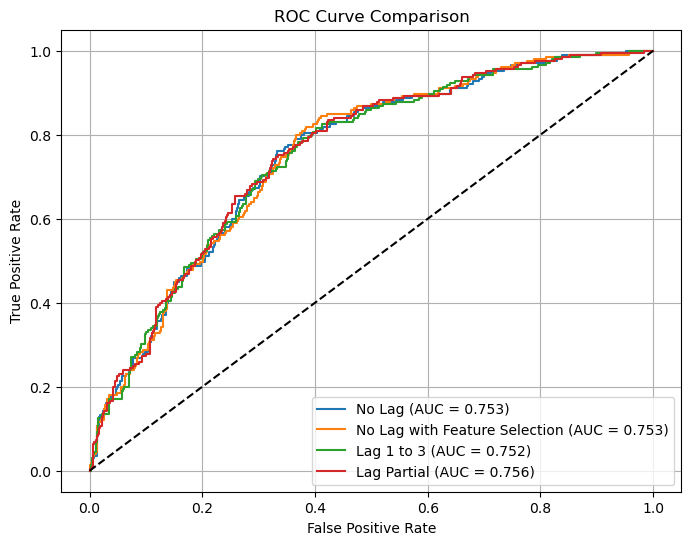

In [62]:
plt.figure(figsize=(8,6))

# No lag
fpr0, tpr0, _ = roc_curve(y_test_ori, y_prob_ori)
auc0 = auc(fpr0, tpr0)
plt.plot(fpr0, tpr0, label=f"No Lag (AUC = {auc0:.3f})")

# No lag with feature selection
fpr0, tpr0, _ = roc_curve(y_test, y_prob_sel)
auc0 = auc(fpr0, tpr0)
plt.plot(fpr0, tpr0, label=f"No Lag with Feature Selection (AUC = {auc0:.3f})")

# Lag 1–3
fpr1, tpr1, _ = roc_curve(y_test_lag3, y_prob_lag3)
auc1 = auc(fpr1, tpr1)
plt.plot(fpr1, tpr1, label=f"Lag 1 to 3 (AUC = {auc1:.3f})")

# Lag partial
fpr2, tpr2, _ = roc_curve(y_test_lag1_partial, y_prob_lag1_partial)
auc2 = auc(fpr2, tpr2)
plt.plot(fpr2, tpr2, label=f"Lag Partial (AUC = {auc2:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

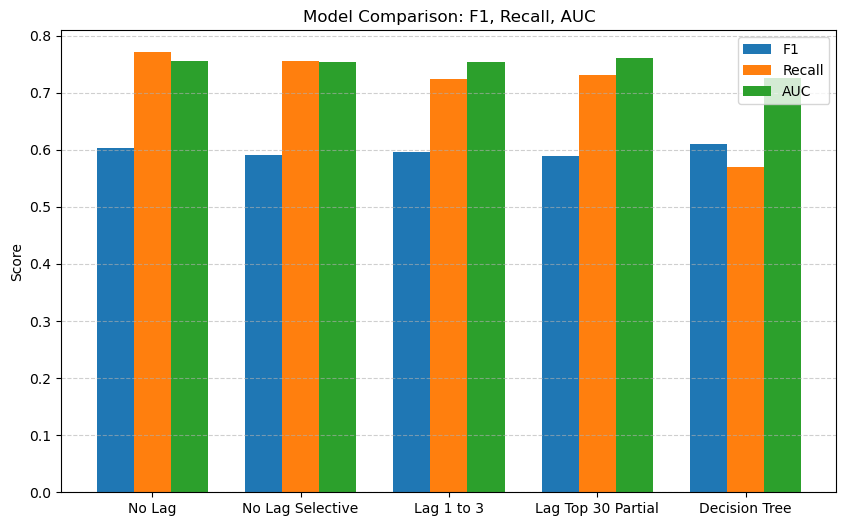

In [63]:
models = ["No Lag","No Lag Selective", "Lag 1 to 3", "Lag Top 30 Partial", "Decision Tree"]

f1_scores = [0.6031, 0.5905, 0.596, 0.5893, 0.610]
recalls =    [0.7707, 0.7561, 0.7233, 0.7313, 0.570]
aucs =       [0.7560, 0.7542, 0.7542, 0.7607, 0.726]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, f1_scores, width, label="F1")
plt.bar(x, recalls, width, label="Recall")
plt.bar(x + width, aucs, width, label="AUC")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison: F1, Recall, AUC")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# Final Model Evaluation (RF+TSCV)

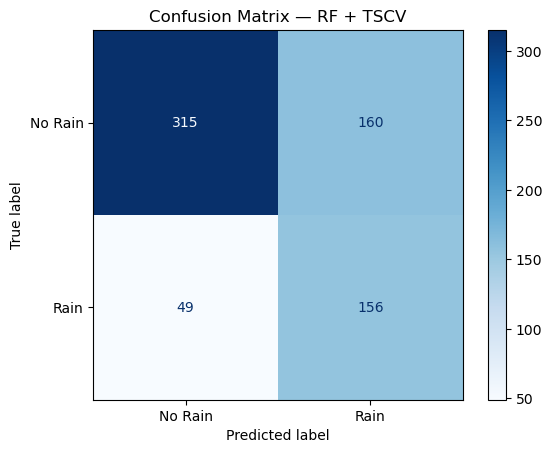

In [64]:
cm = confusion_matrix(y_test_ori, y_pred_ori)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — RF + TSCV")
plt.show()

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_37401/551183129.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(rain_idx, y_test_ori[rain_idx],


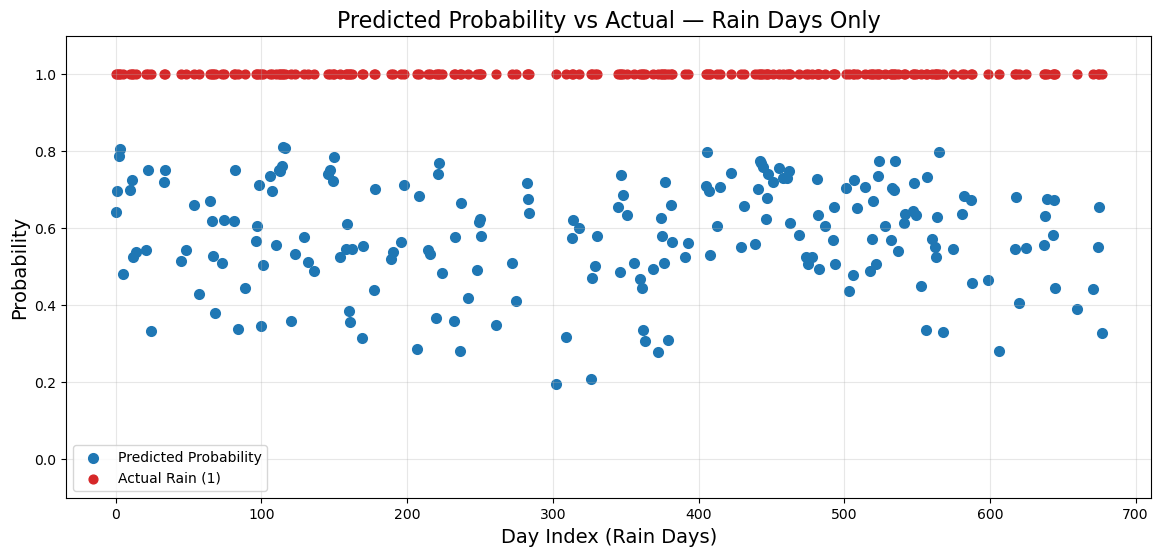

In [65]:
rain_idx = np.where(y_test_ori == 1)[0]

plt.figure(figsize=(14,6))

plt.scatter(rain_idx, y_prob_ori[rain_idx], 
         color="#1f77b4", linewidth=2, label="Predicted Probability")

plt.scatter(rain_idx, y_test_ori[rain_idx], 
            color="#d62728", s=40, label="Actual Rain (1)")

plt.title("Predicted Probability vs Actual — Rain Days Only", fontsize=16)
plt.xlabel("Day Index (Rain Days)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_37401/3394137198.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(rain_idx, y_test_ori[rain_idx],


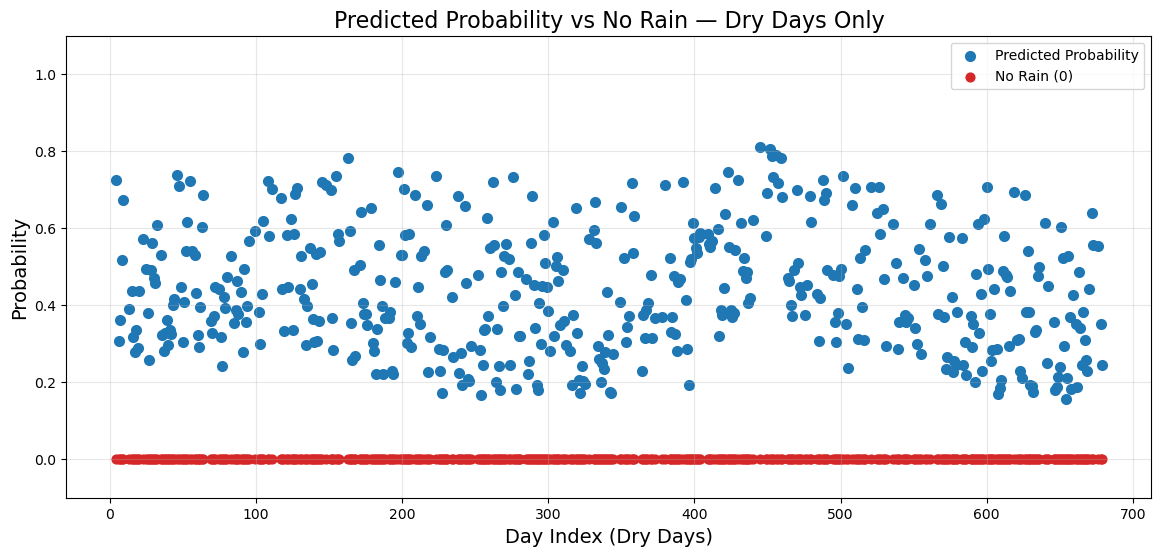

In [66]:
rain_idx = np.where(y_test_ori == 0)[0]

plt.figure(figsize=(14,6))

plt.scatter(rain_idx, y_prob_ori[rain_idx], 
         color="#1f77b4", linewidth=2, label="Predicted Probability")

plt.scatter(rain_idx, y_test_ori[rain_idx], 
            color="#d62728", s=40, label="No Rain (0)")

plt.title("Predicted Probability vs No Rain — Dry Days Only", fontsize=16)
plt.xlabel("Day Index (Dry Days)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Application

In [ ]:
# Pick an example index from the test set
example_idx = X_test_raw.index[555]

# Extract the row (no selector)
example_row = X_test_raw.loc[[example_idx]]

# Actual label
actual_label = y_test_ori.loc[example_idx]

# Predict using the RF model without feature selection
prob = best_rf_TSCV_Ori.predict_proba(example_row)[0, 1]
pred = best_rf_TSCV_Ori.predict(example_row)[0]

print("=== Example Prediction ===")
print("Date index:", example_idx)
print("Predicted probability of rain tomorrow:", round(prob, 3))
print("Predicted class:", pred)
print("Actual RainTomorrow:", actual_label)
print("Correct prediction:", pred == actual_label)

=== Example Prediction ===
Date index: 2021-11-04 00:00:00
Predicted probability of rain tomorrow: 0.273
Predicted class: 0
Actual RainTomorrow: 0
Correct prediction: True
